<!-- 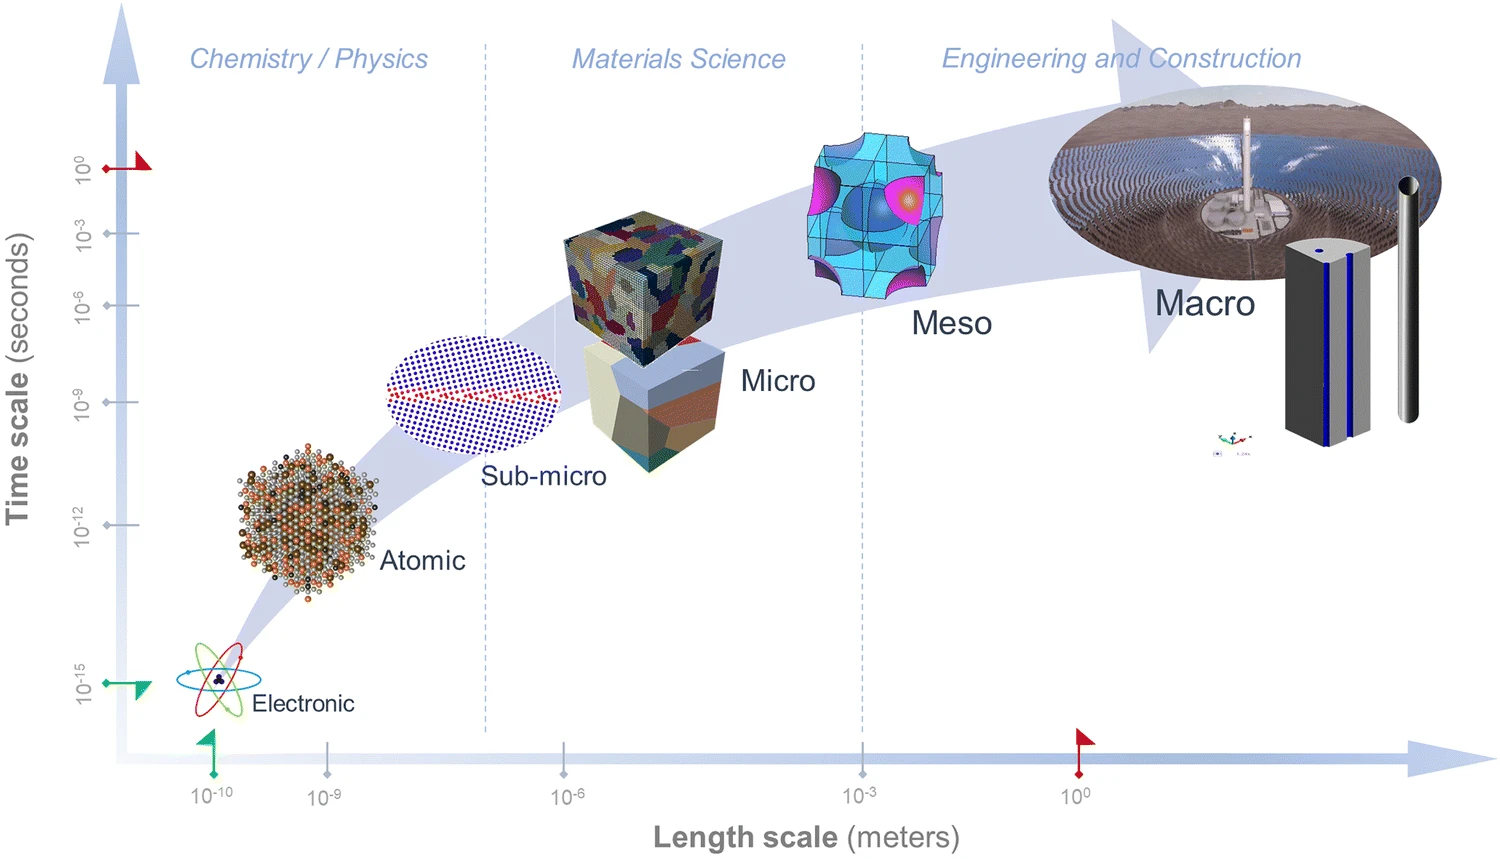 -->

# ODEs: numerical solution and implementation

### Reference Chapter 22, Chapra Textbook Applied Numerical Methods...

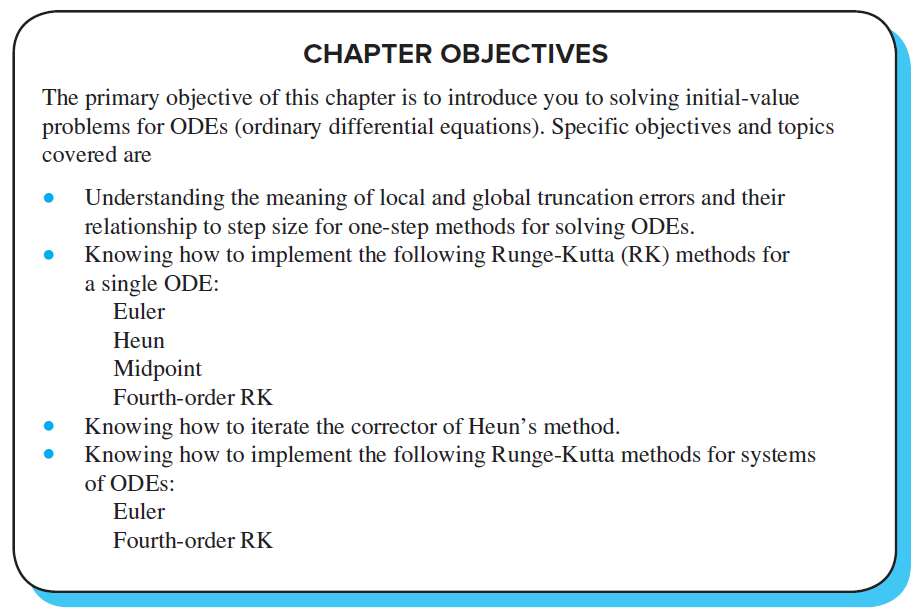

## Consider the following ODE (Ordinary Differential Equation)

$$\frac{dy}{dx} = -2x^3 + 12x^2 - 20x + 8.5$$

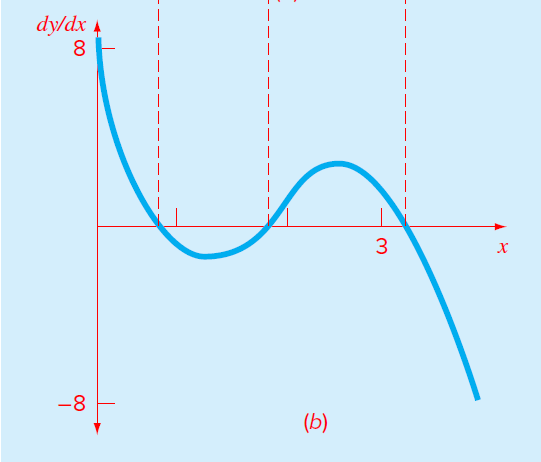

In [1]:
import matplotlib.pyplot as plt
import numpy as np

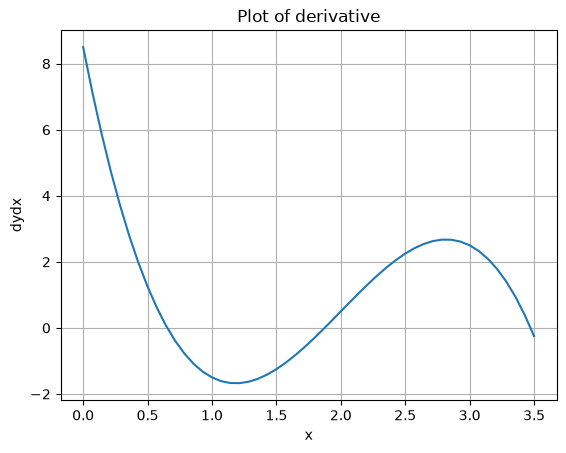

In [2]:
x = np.linspace(0, 3.5, 50) # Define domain for x

# Calculate dy/dx
dydx = -2 * x**3 + 12 * x**2 - 20 * x + 8.5
plt.plot(x, dydx)
plt.xlabel("x")
plt.ylabel("dydx")
plt.title("Plot of derivative")
plt.grid()
plt.show()

### How many solutions do we expect for this ODE?

Integrate: 
$$y = \int \left(-2x^3 + 12x^2 - 20x + 8.5\right) dx$$
$$y = -0.5x^4 + 4x^3 - 10x^2 + 8.5x + C$$

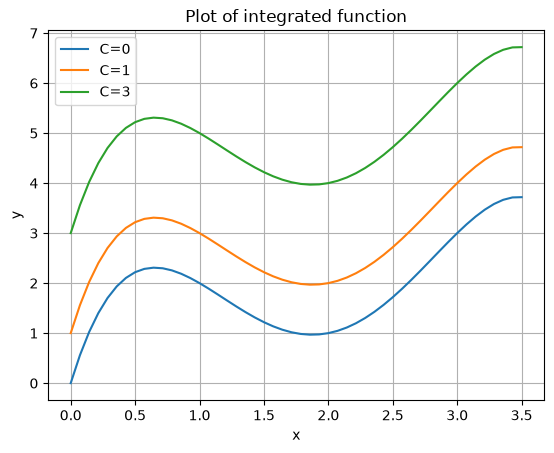

In [8]:
C = 0.0
y = -0.5 * x**4 + 4 * x**3 - 10 * x**2 + 8.5 * x + C
plt.plot(x, y, label="C=0")
C = 1.0
y = -0.5 * x**4 + 4 * x**3 - 10 * x**2 + 8.5 * x + C
plt.plot(x, y, label="C=1")
C = 3.0
y = -0.5 * x**4 + 4 * x**3 - 10 * x**2 + 8.5 * x + C
plt.plot(x, y, label="C=3")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Plot of integrated function")
plt.legend()
plt.grid()
plt.show()

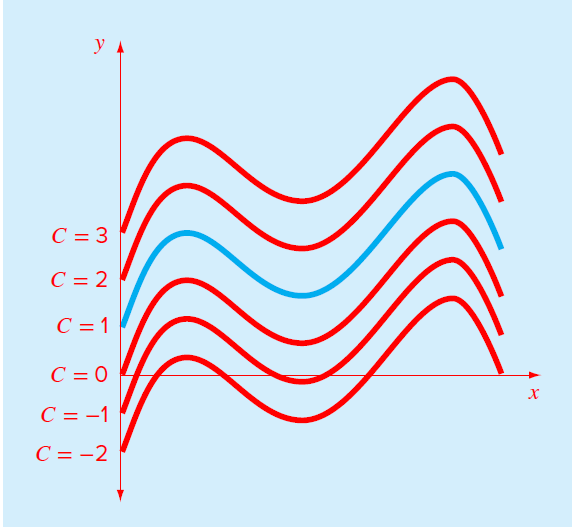
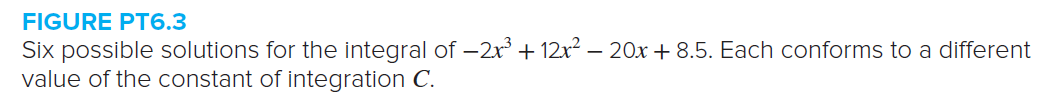

#### Depending upon values of C, we have infinite solutions

Quoting Chapra, "To specify the solution completely, a differential equation needs additional conditions. For first-order ODEs, a type of additional condition called an `initial value` is required to determine the constant and obtain a unique solution."

### How many additional conditions required for 2nd order ODE? Why?

### Few ODEs in materials engineering

Johnson-Mehl-Avrami-Kolmogorov (JMAK) Kinetics: Describes the transformation rate of a phase fraction $Y(t)$:$$\frac{dY}{dt} = k n t^{n-1} (1 - Y)$$

Grain Growth Kinetics: Describes curvature-driven grain boundary migration where the average grain radius $R$ expands over time (simplified form):$$\frac{dR}{dt} = \frac{K}{R} \implies R^2 - R_0^2 = 2Kt$$

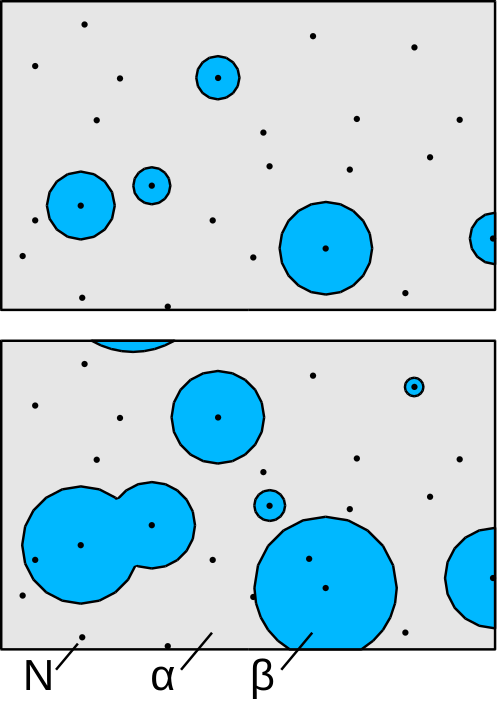

The above images shows the growth of the blue phase in the gray matrix phase. Blue can be considered as ice crystals growing in a water bath.

# Initial Value Problem (1st order ODE)

The above equation was of the form, $$\frac{dy}{dx} = f(x) $$
or, replacing x by t:
$$\frac{dy}{dt} = \dot{y} = f(t) $$

#### General form
In general form, $$\frac{dy}{dt} = \dot{y} = f(y, t) $$
where $$ f(y, t) $$ is also called the slope

#### Let's consider the below simplified case, We derive the analytical solution 

$$\dot{y} = \lambda y$$

$$\frac{dy}{dt} = Ay = \lambda y$$

$$\frac{dy}{y} = \lambda dt$$

$$\ln \left( \frac{y}{y_0} \right) = \lambda t$$

$$y = y_0 e^{\lambda t}$$

Since, this is a 1st order ODE, there is only 1 integration constant required, which is the initial condition. Hence this is called as an **Initial Value Problem**

Assume the following initial condition at `t=0`, `y=1` $\implies y_0 = 0$

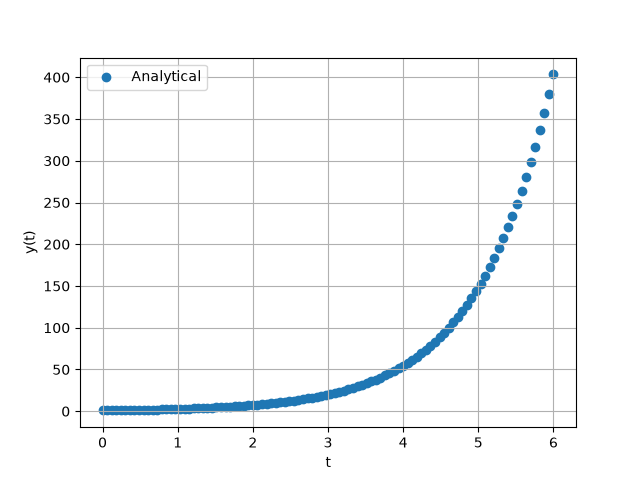

In [2]:
%matplotlib widget

y0 = 1.0
lamda = 1
if lamda == -1:
    y0 = 10
end_time = 6
t_arr = np.linspace(0, end_time, 100)
y_ana = y0*np.exp(lamda*t_arr)
plt.close('all')
plt.scatter(t_arr, y_ana, label="Analytical")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()

## Discretization
Dividing the domain (here time dimension) into finite steps and integrating

In [4]:
dt = 0.1
t_array = np.arange(0, end_time, dt)
timesteps = np.size(t_array)
print(t_array)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5
 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5.  5.1 5.2 5.3
 5.4 5.5 5.6 5.7 5.8 5.9]


## Explicit method (Forward Euler)


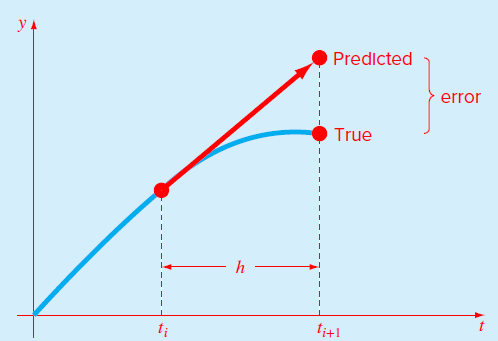

Here we use the slope is used from the **current time step t**
$$\frac{dy}{dt} = \lambda y = f(y_t)$$

$$y_{t+1} = y_t + \frac{dy}{dt} \Delta t$$

$$y_{t+1} = y_t + \lambda y_t \Delta t$$

$$y_{t+1} = y_t(1 + \lambda \Delta t) \quad y_{t+k} = y_t(1 + \lambda \Delta t)^k \Rightarrow \text{Will grow if } (1 + \lambda \Delta t) > 1$$

$$y_{t+1} = y_t(1 + \lambda \Delta t) \quad y_{t+k} = y_t(1 + \lambda \Delta t)^k \Rightarrow \text{Will grow if } (1 + \lambda \Delta t) > 1$$

#### This term $(1 + \lambda \Delta t)$ is the amplification factor or the growth factor
#### The analytical solutions when $\lambda > 0$ are unstable solutions (they keep on growing)
#### The analytical solutions when $\lambda < 0$ are stable solutions (they keep on shrinking)

### Plot with $\lambda$ = =+ve 

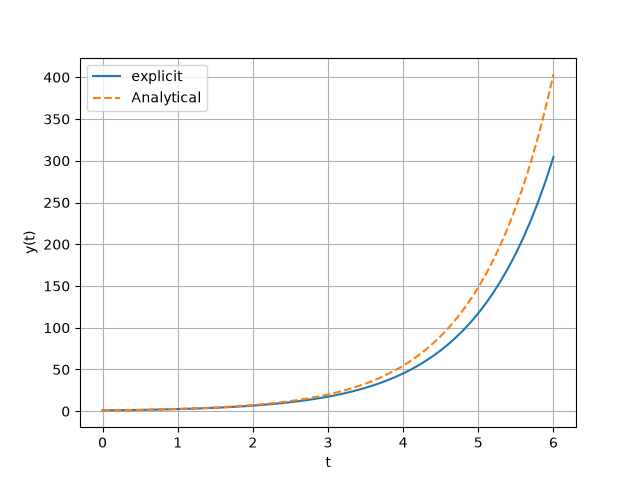

In [11]:
%matplotlib widget
import matplotlib.pyplot as plt
dt = 0.1 # 0.1*30
end_time = 6.0
y0 = 1.0
t_array = np.arange(0, end_time+0.01, dt)
timesteps = np.size(t_array)
y_exp = np.zeros(timesteps)
y_exp[0] = y0
lamda = +1.0
y_ana = y0*np.exp(lamda*t_arr)

for t in range(timesteps-1):
    y_exp[t+1] = y_exp[t]*(1 + lamda*dt) # explicit scheme
plt.close('all')
plt.plot(t_array, y_exp, label='explicit')
plt.plot(t_arr, y_ana, "--", label="Analytical")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()

### Plot with $\lambda$ = =-ve 

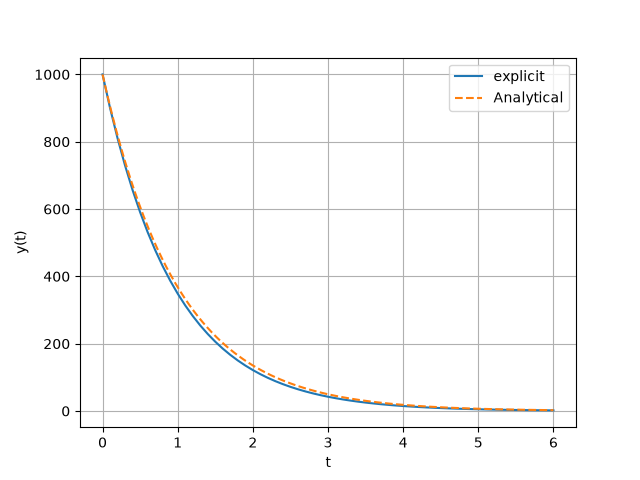

In [13]:
%matplotlib widget
import matplotlib.pyplot as plt
dt = 0.1 # 0.1*30
end_time = 6.0
y0 = 1000
t_array = np.arange(0, end_time+0.01, dt)
timesteps = np.size(t_array)
y_exp = np.zeros(timesteps)
y_exp[0] = y0
lamda = -1.0
y_ana = y0*np.exp(lamda*t_arr)

for t in range(timesteps-1):
    y_exp[t+1] = y_exp[t]*(1 + lamda*dt) # explicit scheme
plt.close('all')
plt.plot(t_array, y_exp, label='explicit')
plt.plot(t_arr, y_ana, "--", label="Analytical")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()

## Accuracy

## Accuracy of Explicit Method (Forward Euler)
Taylor series (TS) expansion:

$$y(t + \Delta t) = y(t) + \Delta t y'(t) + \frac{1}{2!} (\Delta t)^2 y''(t)$$

Explicit Method (EM): $$y(t + \Delta t) = y(t) + \Delta t y'(t)$$

Error Calculation:$$\begin{aligned} \text{error} &= TS - EM \\ &= \frac{1}{2!} (\Delta t)^2 y''(t) + O(\Delta t)^3 \\ &= O(\Delta t)^2 \end{aligned}$$

$$\text{Error} = O(\Delta t)^2$$ $ \rightarrow $ Also called as **local truncation error**, i.e. introduced in a single step 

$$\text{Accuracy} = O(\Delta t)^1$$

**Global Truncation Error**: Cumulative error over all N timesteps
$$ N = \text{end Time} / \Delta t $$
$$\text{Error } = O(\Delta t)^2 \times N = O(\Delta t)^2 / \Delta t = O(\Delta t) $$

## Plotting the error with $\Delta t$

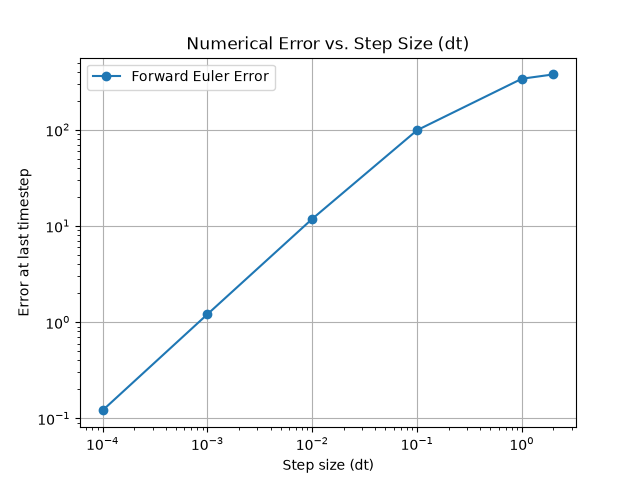

In [10]:
y0 = 1.0
lamda = 1.0
end_time = 6.0

# Range of dt values
dt_values = [2.0, 1.0, 0.1, 0.01, 0.001, 0.0001]
errors = []

for dt in dt_values:
    t_array = np.arange(0, end_time+0.000001, dt)
    y_exp = np.zeros(len(t_array))
    y_exp[0] = y0

    # Explicit Euler integration
    for t in range(len(t_array) - 1):
        y_exp[t + 1] = y_exp[t] * (1 + lamda * dt)

    # Exact analytical solution at end_time
    y_exact = y0 * np.exp(lamda * t_array[-1])

    # Absolute global error at the final time step
    err = np.abs(y_exact - y_exp[-1])
    errors.append(err)

# Plotting Error vs dt
plt.figure()
# plt.plot(dt_values, errors, "o-", label="Forward Euler Error")
plt.loglog(dt_values, errors, "o-", label="Forward Euler Error")
plt.xlabel("Step size (dt)")
plt.ylabel("Error at last timestep")
plt.title("Numerical Error vs. Step Size (dt)")
plt.grid(True)
plt.legend()
plt.show()

## Implicit Method (Backward Euler)

Below shows the derivation using an implicit approach, where the derivative is evaluated at the future time step $t+1$.

$$\frac{dy}{dt} = \lambda y_{t+1} = f(y_{t+1})$$

$$y_{t+1} = y_t + (\lambda y_{t+1}) \Delta t$$

$$y_{t+1} (1 - \lambda \Delta t) = y_t$$

$$y_{t+1} = \frac{y_t}{(1 - \lambda \Delta t)}$$

$$y_{t+2} = \frac{y_{t+1}}{(1 - \lambda \Delta t)} = \frac{y_t}{(1 - \lambda \Delta t)^2}$$

$$y_{t+k} = \frac{y_t}{(1 - \lambda \Delta t)^k}$$

<!-- <div class="alert alert-block alert-success"><b>Tip:</b> Great optimization trick!</div> -->
<div class="alert alert-block alert-warning"> Why would I make it so complex? What's the need to go to t+1 and find the slope?</div>



## Accuracy of Implicit Method (Backward Euler)

Taylor series (TS) expansion about $t$:
$$ \color{green} y(t + \Delta t) = y(t) + \Delta t \, y'(t) + \frac{1}{2!} (\Delta t)^2 y''(t) + O((\Delta t)^3) ... (1) $$

Implicit Method (IM):$$y(t + \Delta t) = y(t) + \Delta t \, \textcolor{red}{y'(t + \Delta t)}$$

Expanding the derivative term $\textcolor{red}{y'(t + \Delta t)}$ around $t$:

$$\textcolor{red}{y'(t + \Delta t)} = y'(t) + \Delta t \, y''(t) + O((\Delta t)^2)$$

Substituting this back into IM formula: 

$$ \color{blue} y(t + \Delta t) = y(t) + \Delta t \, y'(t) + (\Delta t)^2 y''(t) + O((\Delta t)^3) ... (2) $$

Error Calculation:$$\text{error} = TS - IM$$ 

$$= -\frac{1}{2!} (\Delta t)^2 y''(t) + O((\Delta t)^3)$$

$$= O((\Delta t)^2)$$$$\mathbf{Error = O((\Delta t)^2)}$$

$\implies$ Also called as local truncation error, i.e. introduced in a single step

**Global Truncation Error**: Cumulative error over all N timesteps
$$ N = \text{end Time} / \Delta t $$
$$\text{Error } = O(\Delta t)^2 \times N = O(\Delta t)^2 / \Delta t = O(\Delta t) $$

**The errors in FE (Forward Euler) and (Backward Euler) are of the same order**

### $\Delta t = 0.1$

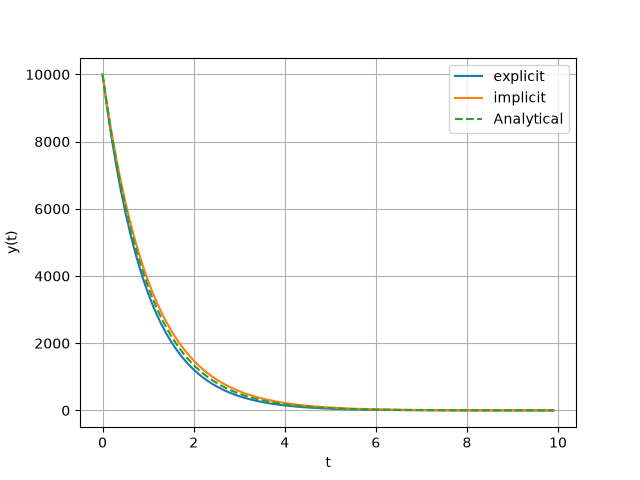

In [37]:
%matplotlib widget
y0 = 10000.0
lamda = -1.0
end_time = 10
dt = 0.1
t_array = np.arange(0, end_time, dt)
timesteps = np.size(t_array)

y_exp = np.zeros_like(t_array)
y_exp[0] = y0
y_imp = y_exp.copy()

y_ana = y0*np.exp(lamda*t_array)
for t in range(timesteps-1):
    y_exp[t+1] = y_exp[t]*(1 + lamda*dt) # explicit scheme
    y_imp[t+1] = y_imp[t]/(1 - lamda*dt) # implicit scheme

plt.close('all')
plt.plot(t_array, y_exp, label='explicit')
plt.plot(t_array, y_imp, label='implicit')
plt.plot(t_array, y_ana, "--", label="Analytical")

plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()

### $\Delta t = 0.5$

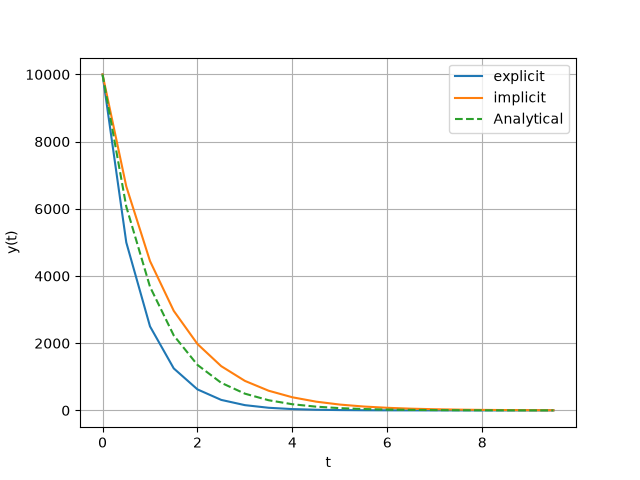

In [38]:
%matplotlib widget
y0 = 10000.0
lamda = -1.0
end_time = 10
dt = 0.5
t_array = np.arange(0, end_time, dt)
timesteps = np.size(t_array)

y_exp = np.zeros_like(t_array)
y_exp[0] = y0
y_imp = y_exp.copy()

y_ana = y0*np.exp(lamda*t_array)
for t in range(timesteps-1):
    y_exp[t+1] = y_exp[t]*(1 + lamda*dt) # explicit scheme
    y_imp[t+1] = y_imp[t]/(1 - lamda*dt) # implicit scheme

plt.close('all')
plt.plot(t_array, y_exp, label='explicit')
plt.plot(t_array, y_imp, label='implicit')
plt.plot(t_array, y_ana, "--", label="Analytical")

plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()

### $\Delta t = 0.8$

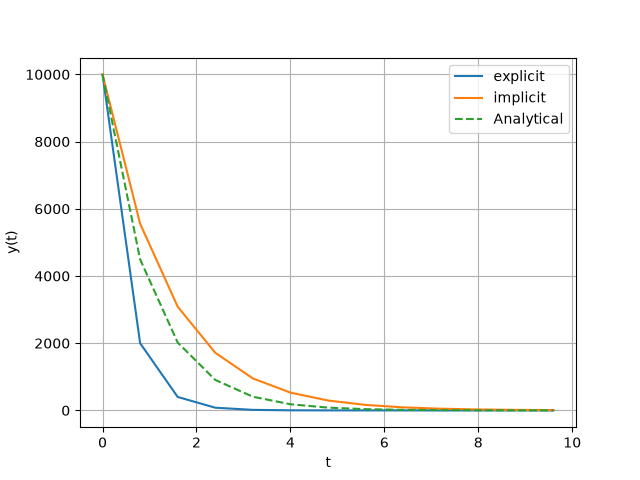

In [39]:
%matplotlib widget
y0 = 10000.0
lamda = -1.0
end_time = 10
dt = 0.8
t_array = np.arange(0, end_time, dt)
timesteps = np.size(t_array)

y_exp = np.zeros_like(t_array)
y_exp[0] = y0
y_imp = y_exp.copy()

y_ana = y0*np.exp(lamda*t_array)
for t in range(timesteps-1):
    y_exp[t+1] = y_exp[t]*(1 + lamda*dt) # explicit scheme
    y_imp[t+1] = y_imp[t]/(1 - lamda*dt) # implicit scheme

plt.close('all')
plt.plot(t_array, y_exp, label='explicit')
plt.plot(t_array, y_imp, label='implicit')
plt.plot(t_array, y_ana, "--", label="Analytical")

plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()

### $\Delta t = 1.0$

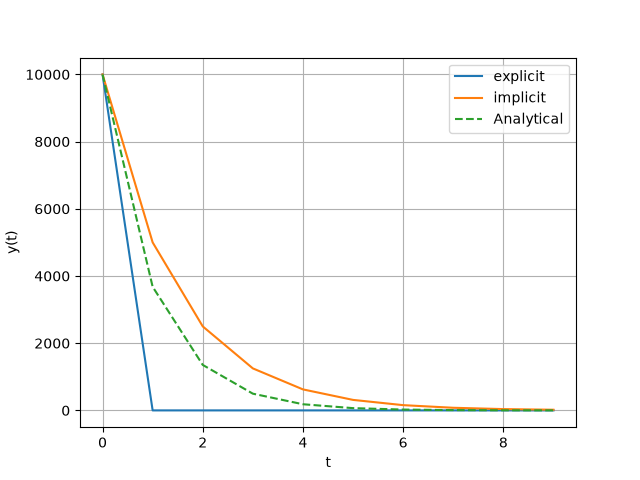

In [42]:
%matplotlib widget
y0 = 10000.0
lamda = -1.0
end_time = 10
dt = 1.0
t_array = np.arange(0, end_time, dt)
timesteps = np.size(t_array)

y_exp = np.zeros_like(t_array)
y_exp[0] = y0
y_imp = y_exp.copy()

y_ana = y0*np.exp(lamda*t_array)
for t in range(timesteps-1):
    y_exp[t+1] = y_exp[t]*(1 + lamda*dt) # explicit scheme
    y_imp[t+1] = y_imp[t]/(1 - lamda*dt) # implicit scheme

plt.close('all')
plt.plot(t_array, y_exp, label='explicit')
plt.plot(t_array, y_imp, label='implicit')
plt.plot(t_array, y_ana, "--", label="Analytical")

plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()

### $\Delta t = 1.4$

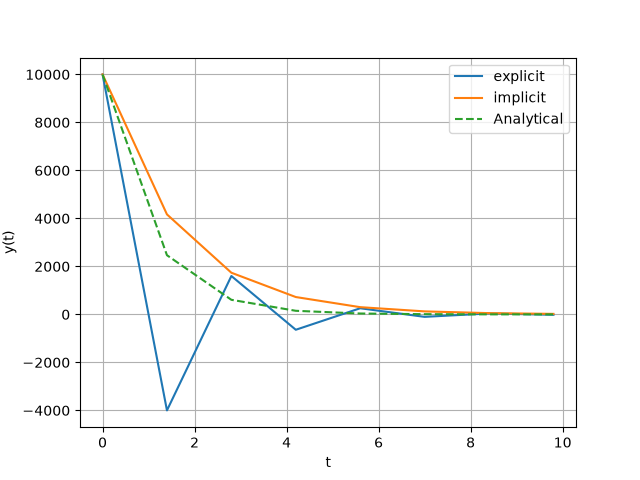

In [47]:
%matplotlib widget
y0 = 10000.0
lamda = -1.0
end_time = 10
dt = 1.4
t_array = np.arange(0, end_time, dt)
timesteps = np.size(t_array)

y_exp = np.zeros_like(t_array)
y_exp[0] = y0
y_imp = y_exp.copy()

y_ana = y0*np.exp(lamda*t_array)
for t in range(timesteps-1):
    y_exp[t+1] = y_exp[t]*(1 + lamda*dt) # explicit scheme
    y_imp[t+1] = y_imp[t]/(1 - lamda*dt) # implicit scheme

plt.close('all')
plt.plot(t_array, y_exp, label='explicit')
plt.plot(t_array, y_imp, label='implicit')
plt.plot(t_array, y_ana, "--", label="Analytical")

plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()

### $\Delta t = 1.8$

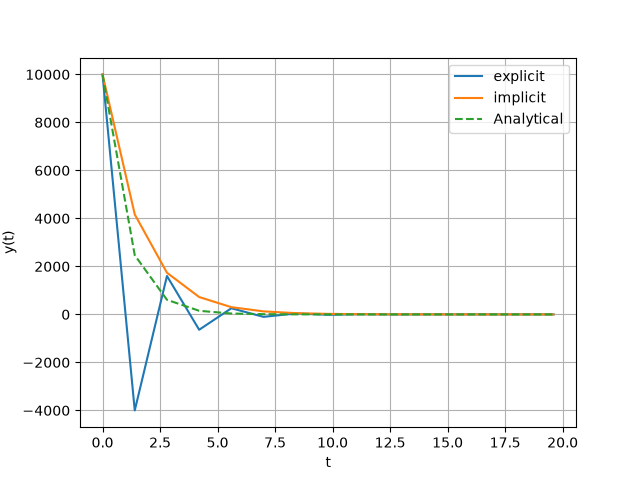

In [50]:
%matplotlib widget
y0 = 10000.0
lamda = -1.0
end_time = 20
dt = 1.4
t_array = np.arange(0, end_time, dt)
timesteps = np.size(t_array)

y_exp = np.zeros_like(t_array)
y_exp[0] = y0
y_imp = y_exp.copy()

y_ana = y0*np.exp(lamda*t_array)
for t in range(timesteps-1):
    y_exp[t+1] = y_exp[t]*(1 + lamda*dt) # explicit scheme
    y_imp[t+1] = y_imp[t]/(1 - lamda*dt) # implicit scheme

plt.close('all')
plt.plot(t_array, y_exp, label='explicit')
plt.plot(t_array, y_imp, label='implicit')
plt.plot(t_array, y_ana, "--", label="Analytical")

plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()

### $\Delta t = 2.0$

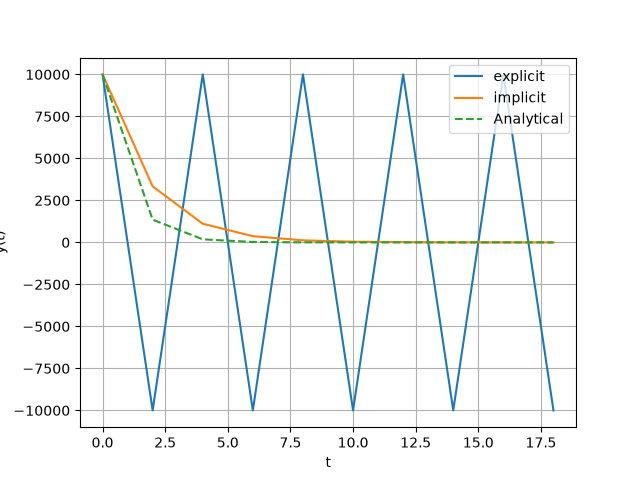

In [51]:
%matplotlib widget
y0 = 10000.0
lamda = -1.0
end_time = 20
dt = 2.0
t_array = np.arange(0, end_time, dt)
timesteps = np.size(t_array)

y_exp = np.zeros_like(t_array)
y_exp[0] = y0
y_imp = y_exp.copy()

y_ana = y0*np.exp(lamda*t_array)
for t in range(timesteps-1):
    y_exp[t+1] = y_exp[t]*(1 + lamda*dt) # explicit scheme
    y_imp[t+1] = y_imp[t]/(1 - lamda*dt) # implicit scheme

plt.close('all')
plt.plot(t_array, y_exp, label='explicit')
plt.plot(t_array, y_imp, label='implicit')
plt.plot(t_array, y_ana, "--", label="Analytical")

plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()

### $\Delta t = 2.2$

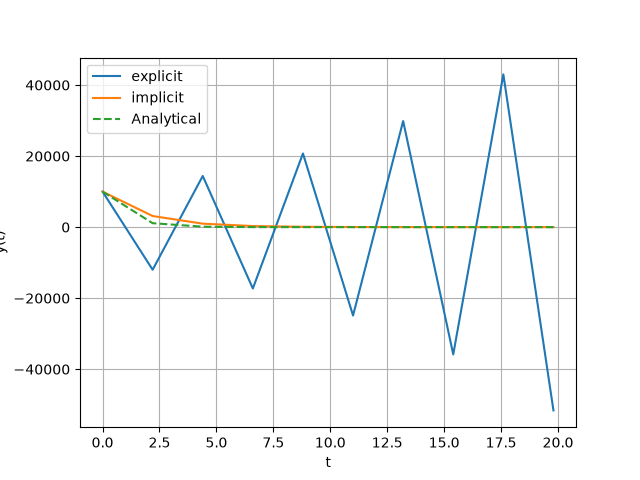

In [55]:
%matplotlib widget
y0 = 10000.0
lamda = -1.0
end_time = 20
dt = 2.2
t_array = np.arange(0, end_time, dt)
timesteps = np.size(t_array)

y_exp = np.zeros_like(t_array)
y_exp[0] = y0
y_imp = y_exp.copy()

y_ana = y0*np.exp(lamda*t_array)
for t in range(timesteps-1):
    y_exp[t+1] = y_exp[t]*(1 + lamda*dt) # explicit scheme
    y_imp[t+1] = y_imp[t]/(1 - lamda*dt) # implicit scheme

plt.close('all')
plt.plot(t_array, y_exp, label='explicit')
plt.plot(t_array, y_imp, label='implicit')
plt.plot(t_array, y_ana, "--", label="Analytical")

plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()

## Stability of explicit and implicit schemes

## Explicit Scheme

$$\frac{dy}{dt} = \lambda y = \dot{y}$$

$$y_{t+k} = (1 + \lambda \Delta t)^k y_0$$ 

If $\lambda < 0 \implies y(t)$ analytically should decrease. Let's see if this holds true for the explicit discretization scheme. 

For the explicit scheme solution to keep on decreasing: $$|(1 + \lambda \Delta t)|^k < 1$$
$$|1 + \lambda \Delta t| < 1$$
$$-2 < \lambda \Delta t < 0$$

## Implicit Scheme

$$y_{t+k} = \frac{1}{(1 - \lambda \Delta t)^k} y_t$$ 

For this to be **unstable** (i.e. solution should blow up, $\implies$ denominator $\rightarrow 0$) (given $\lambda < 0$): $$| 1 - \lambda \Delta t| < 1$$

$$-1 < 1 - \lambda \Delta t < 1$$

$$-2 < -\lambda \Delta t < 0$$

$$2 > \lambda \Delta t > 0$$

i.e. for **unstable** solution: $$\lambda \Delta t \in (0, 2)$$

for **stable** solution $$\lambda \Delta t \notin (0, 2)$$

### Implicit Scheme (Stability Map in Complex Plane) --> We are only interested in the stability limits along the real axis in this course.
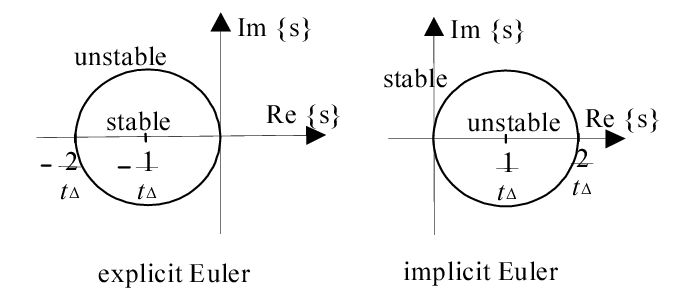

### Hence Implicit scheme is UNCONDITIONALLY STABLE

## Conclusions for the case of $$\frac{dy}{dt} = \lambda y$$ with $\lambda < 0.0 $, i.e. a stable function which decreases with time:

1. The explicit method is **unstable** for higher values of $\Delta t$. The region of stability is $-2 ≤ \lambda \Delta t ≤ 0$. This is called as **CONDITIONALLY STABLE**
2. The implicit method is stable for all values of $\Delta t$. This is called as **UN-CONDITIONALLY STABLE**
3. Both these methods have the same order of accuracy

## Centred Difference Method (2nd Order Accurate Method)

Taylor series (TS) expansions about $t$:

$$y(t + \Delta t) = y(t) + \Delta t \, y'(t) + \frac{1}{2!} (\Delta t)^2 y''(t) + \frac{1}{3!} (\Delta t)^3 y'''(t) + O((\Delta t)^4)$$

$$y(t - \Delta t) = y(t) - \Delta t \, y'(t) + \frac{1}{2!} (\Delta t)^2 y''(t) - \frac{1}{3!} (\Delta t)^3 y'''(t) + O((\Delta t)^4)$$ 

Subtracting $y(t - \Delta t)$ from $y(t + \Delta t)$: 

$$y(t + \Delta t) - y(t - \Delta t) = 2 \Delta t \, y'(t) + \frac{2}{3!} (\Delta t)^3 y'''(t) + O((\Delta t)^5)$$

Rearranging for $y(t + \Delta t)$:

$$y(t + \Delta t) = y(t - \Delta t) + 2 \Delta t \, y'(t) + \frac{1}{3} (\Delta t)^3 y'''(t) + O((\Delta t)^5)$$

Central Difference Method (CDM):

$$y(t + \Delta t) = y(t - \Delta t) + 2 \Delta t \, y'(t)$$

Error Calculation (Step Truncation Error):$$\text{error} = TS - CDM$$

$$= \frac{1}{3} (\Delta t)^3 y'''(t) + O((\Delta t)^5)$$

$$= O((\Delta t)^3)$$$$\mathbf{\text{Local Step Error} = O((\Delta t)^3)}$$

## Summary
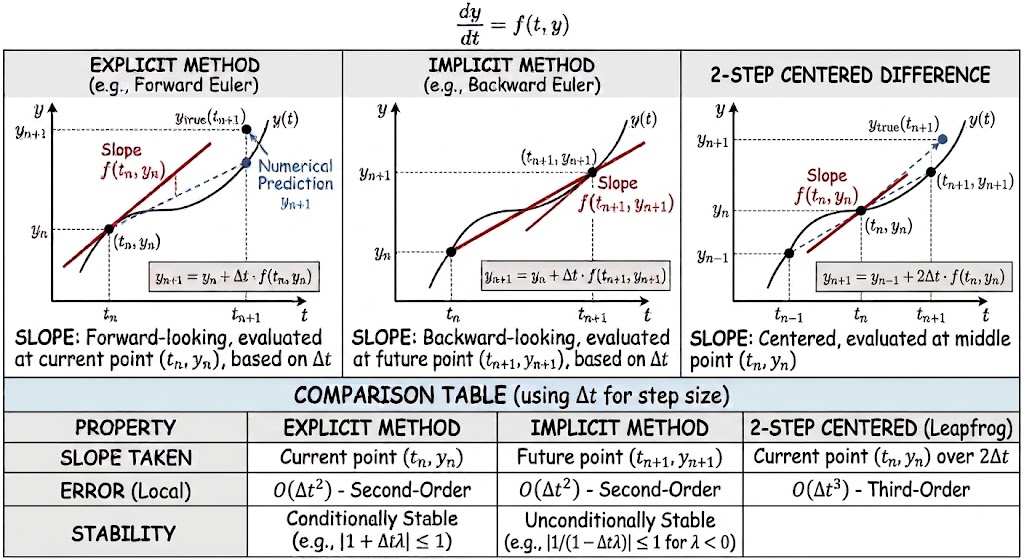

## Centered difference

$$y_{t+1} = y_t + y'_t \Delta t + \frac{1}{2!} y''_t (\Delta t)^2 + \frac{1}{3!} y'''_t (\Delta t)^3 + O(\Delta t)^4 \quad -(1)$$

$$y_{t-1} = y_t - y'_t \Delta t + \frac{1}{2!} y''_t (\Delta t)^2 - \frac{1}{3!} y'''_t (\Delta t)^3 + O(\Delta t)^4 \quad -(2)$$

$$(1) - (2)$$

$$y_{t+1} - y_{t-1} = 2y'_t \Delta t + \frac{2}{3!} y'''_t (\Delta t)^3 + O(\Delta t)^5$$

$$\frac{y_{t+1} - y_{t-1}}{2\Delta t} = y'_t + \frac{1}{6} y'''_t (\Delta t)^2$$

$$y'_t = \frac{y_{t+1} - y_{t-1}}{2\Delta t} + \frac{1}{6} y'''_t (\Delta t)^2$$

$$\text{i.e. } 2^{\text{nd}} \text{ order error in the derivative}$$

From this find $y_{t+1}$, by multiplying throughout by $\Delta t$ and using Eqno 1 and 2, and the Error term is of order of $O(\Delta t)^3$ $\implies$ 2nd order accurate

## Predictor Corrector Method

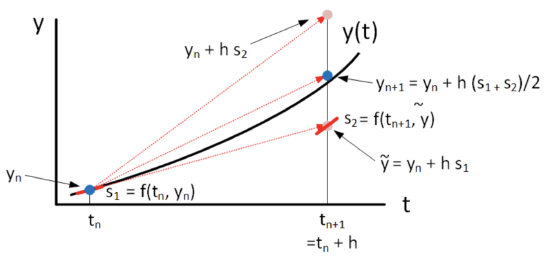

1. Be at $t = t_n$ and compute the slope at this point, $s_1 = f(t_n, y_n)$. 

2. Use this slope to estimate the solution’s value at $t_{n+1}$ using standard forward Euler: $\tilde{y}(t_{n+1}) = y(t_n) + h f(t_n, y_n)$. Here $h = \Delta t$

*We denote this point $\tilde{y}(t_{n+1})$ using a tilde $\sim$ since it’s an intermediate step towards our solution.* 

3. At this point $(t_{n+1}, \tilde{y}_{n+1})$ compute the slope $s_2 = f(t_{n+1}, \tilde{y}_{n+1})$.

4. Average these two slopes to compute the forward step: 
$$y(t_{n+1}) = y(t_n) + \frac{h}{2} (s_1 + s_2) $$

## The RK2 Algorithm (Predictor Corrector as above)

To solve $y' = f(t, y)$, the RK2 method uses a mid-point or average slope: Predictor ($k_1$): Calculate the slope at the beginning of the interval.
$$k_1 = f(t_n, y_n)$$
Corrector ($k_2$): Calculate the slope at the end of the interval using the predictor.
$$k_2 = f(t_n + \Delta t, y_n + \Delta t k_1)$$
Final Update:$$y_{n+1} = y_n + \frac{\Delta t}{2}(k_1 + k_2)$$

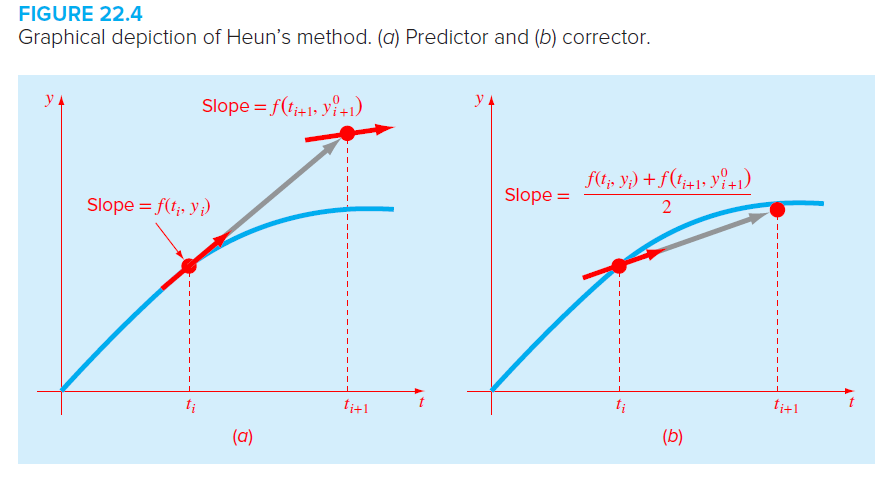

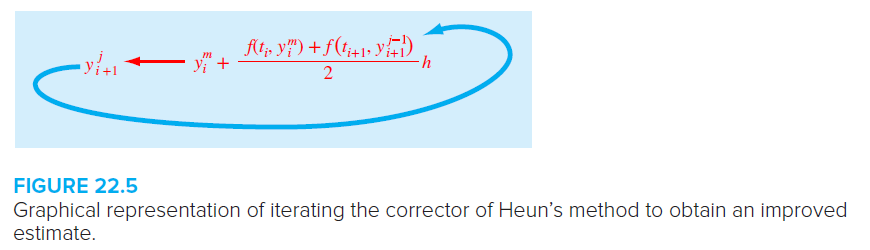

## All methods comparison: Show for different $\Delta t$

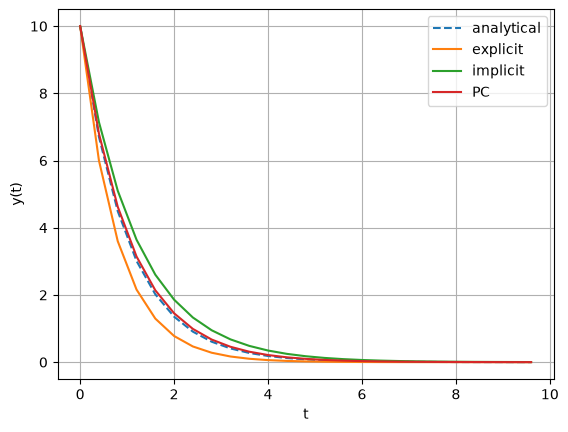

In [60]:
%matplotlib inline
dt = 0.4
end_time = 10
y0 = 10
lamda = -1
t_array = np.arange(0, end_time, dt)
timesteps = np.size(t_array)

y_exp = np.zeros(timesteps)
y_imp = np.zeros(timesteps)
y_pc = np.zeros(timesteps)
y_exp[0] = y0
y_imp[0] = y0
y_pc[0] = y0
for t in range(timesteps-1):
    y_exp[t+1] = y_exp[t]*(1 + lamda*dt) # explicit scheme
    y_imp[t+1] = y_imp[t]/(1 - lamda*dt) # implicit scheme
    
    # Predictor-Corrector (Heun)
    y_tilde = y_pc[t] + dt*lamda*y_pc[t]
    slope_avg = ( lamda*y_pc[t] + lamda*y_tilde )/2.0
    y_pc[t+1] = y_pc[t] + dt*slope_avg
    
y_ana = y0*np.exp(lamda*t_array)

plt.close('all')
plt.plot(t_array, y_ana, '--', label='analytical')
plt.plot(t_array, y_exp, label='explicit')
plt.plot(t_array, y_imp, label='implicit')
plt.plot(t_array, y_pc, label='PC')

plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()

## RK2 method (accuracy)

The Runge-Kutta 2nd Order (RK2) method, also called as Heun's Method or the Predictor-Corrector method, is *designed* to cancel out the **$O(\Delta t)^2$** error term found in the Forward Euler method, resulting in a higher order of accuracy.

The 2 in RK2 means 2nd order accurate, i.e. error is of **$O(\Delta t)^3$**

*The derivation of accuracy of RK2 will not be covered in this course.*

# RK4 
### 4 in RK4 means 4th order accurate (i.e. $O(\Delta t^4)$), i.e. local truncation error of 5th order $O(\Delta t^5)$
Also, needs 4 slope evaluations

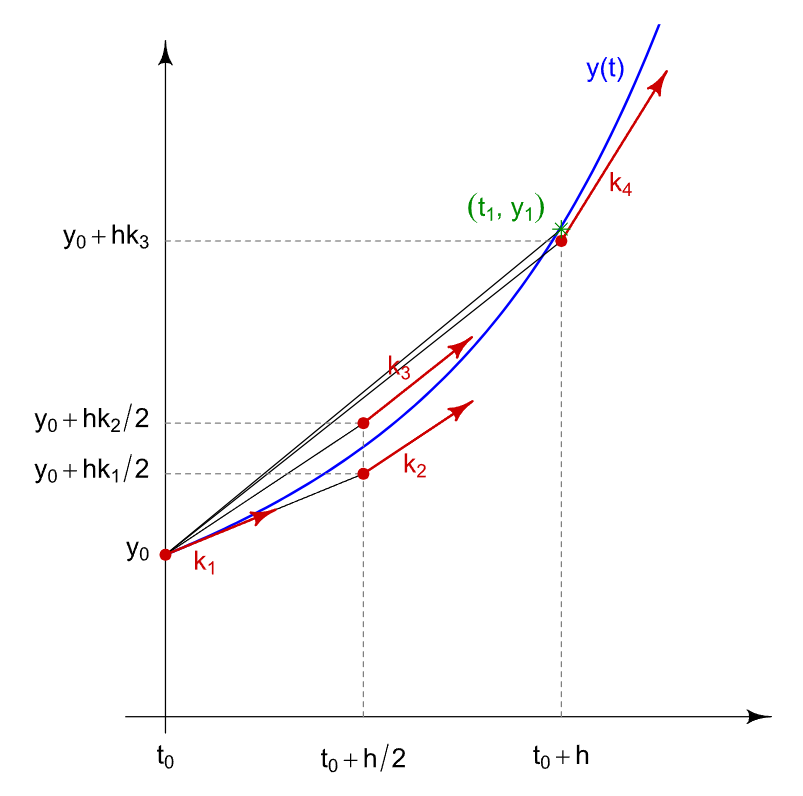

## The RK4 Algorithm

To calculate the value at the next time step $y_{t+1}$ with step size $h = \Delta t$: 
### Compute Four Slopes ($k$ values) 

$k_1$ (Slope at the beginning): 

$$k_1 = f(t_n, y_n)$$

$k_2$ (Slope at the midpoint, using $k_1$): 

$$k_2 = f\left(t_n + \frac{h}{2}, y_n + h\frac{k_1}{2}\right)$$

$k_3$ (Slope at the midpoint, using $k_2$):
$$k_3 = f\left(t_n + \frac{h}{2}, y_n + h\frac{k_2}{2}\right)$$

$k_4$ (Slope at the end, using $k_3$):$$k_4 = f(t_n + h, y_n + h k_3)$$ 

### Final Update
The next value is a weighted average of these four slopes, where the midpoint slopes carry more weight:$$y_{n+1} = y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$